# Predicting Peak Electricity Demand in Massachusetts Using Weather, Load, Renewable Generation, and Consumer Behavior

## Introduction
<p align="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS1qbmBJ6c9Wma3i2UhiRgKJda6EqOqR0HhGvHgHtlM0N7SlizAsOUzRUg&s=10" alt="Massachusetts Grid" width="500">
</p>

### Background

Electricity demand forecasting is one of the most consequential prediction problems in modern infrastructure. Grid operators like ISO New England (ISO-NE), the regional transmission organization responsible for keeping the lights on across Massachusetts and the rest of New England, must balance electricity supply and demand in real time, every hour of every day. Under-forecasting demand risks blackouts and emergency power purchases at extreme prices; over-forecasting wastes generation capacity and drives up costs for ratepayers. As the region's energy mix shifts toward renewable generation — sources that are inherently weather-dependent and less predictable than traditional fossil-fuel plants — the ability to accurately anticipate *both* demand and supply-side variability has become increasingly critical to grid reliability.

This project focuses specifically on **peak demand** — the highest-stress hours for the grid — because these are the hours that determine infrastructure investment, capacity market pricing, and the risk of service disruptions. Understanding *what conditions drive extreme peaks* (rather than just forecasting average demand) is directly useful to utilities, grid planners, and policymakers making decisions about generation capacity and demand-response programs.

### Problem Statement

This project asks two connected questions:

1. **Can we accurately forecast hourly electricity demand** in the ISO-NE region using historical load, weather, renewable generation, and calendar/behavioral features?
2. **What conditions are most associated with extreme peak demand events**, and do those conditions differ by season?

To answer these, four modeling approaches are compared in increasing sophistication: a naive seasonal-average **baseline**, a classical statistical model (**SARIMAX**), modern gradient-boosted **machine learning models** (XGBoost and LightGBM), and an **ensemble** of the strongest performers. The best-performing model is then interrogated using SHAP (SHapley Additive exPlanations) to identify the specific conditions the model associates with extreme demand, separately for winter and summer peak periods.

### Data Sources

This project uses three real, publicly available data sources:

- **Electricity demand**: hourly load data for the ISO-NE balancing authority, sourced from the U.S. Energy Information Administration's (EIA) [Hourly Electric Grid Monitor API](https://www.eia.gov/electricity/gridmonitor/) ([API documentation](https://www.eia.gov/opendata/)).
- **Weather**: hourly historical temperature, humidity, wind speed, and solar radiation for Boston, MA, sourced from the [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api).
- **Renewable generation**: hourly solar and wind generation for the ISO-NE region, also sourced from the EIA's [Electricity Data API](https://www.eia.gov/opendata/browser/electricity/rto/fuel-type-data).

Consumer behavior is represented through calendar-based proxy features (hour of day, day of week, weekend/holiday flags), since individual smart-meter data at the consumer level is not publicly available.

This data-validation step is documented here deliberately: verifying data integrity before modeling is a critical, and often overlooked, part of the data science process, and the discovery materially changed the direction and credibility of this project's findings.

In [150]:
import requests
import pandas as pd

API_KEY = "Bj6BS7mSqsyJXmbNbLmc7ywn2bUfE6f1GMRr4G4L"

def get_eia_data(start_date, end_date, api_key, offset=0, length=5000):
    url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"
    params = {
        "api_key": api_key,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": "ISNE",
        "facets[type][]": "D",
        "start": start_date,
        "end": end_date,
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "offset": offset,
        "length": length
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

all_records = []
offset = 0
start_date = "2021-01-01T00"
end_date = "2023-12-31T23"

while True:
    data = get_eia_data(start_date, end_date, API_KEY, offset=offset)
    records = data["response"]["data"]
    if not records:
        break
    all_records.extend(records)
    offset += 5000
    print(f"Pulled {len(all_records)} rows so far...")
    if len(records) < 5000:
        break

df = pd.DataFrame(all_records)
df["period"] = pd.to_datetime(df["period"])
df = df.sort_values("period").set_index("period")
df = df.rename(columns={"value": "Demand (MW)"})

print(df.shape)
df[["Demand (MW)"]].head(10)

Pulled 5000 rows so far...
Pulled 10000 rows so far...
Pulled 15000 rows so far...
Pulled 20000 rows so far...
Pulled 25000 rows so far...
Pulled 26279 rows so far...
(26279, 6)


,Demand (MW)
period,
2021-01-01 00:00:00,15907
2021-01-01 01:00:00,15211
2021-01-01 02:00:00,14544
2021-01-01 03:00:00,13928
2021-01-01 04:00:00,13237
2021-01-01 05:00:00,12571
2021-01-01 06:00:00,12480
2021-01-01 07:00:00,12373
2021-01-01 08:00:00,12148


In [151]:
df["Demand (MW)"] = pd.to_numeric(df["Demand (MW)"], errors="coerce")

# Check for any missing values 
print(df["Demand (MW)"].isna().sum())

1


In [152]:
df["hour"] = df.index.hour
df["month"] = df.index.month

print(df.groupby("hour")["Demand (MW)"].mean())
print(df.groupby("month")["Demand (MW)"].mean())

hour
0     15524.610046
1     15134.361644
2     14438.285845
3     13476.699543
4     12520.063927
5     11875.147166
6     11545.074954
7     11375.506849
8     11298.424658
9     11363.753425
10    11632.763470
11    12237.927854
12    12930.073973
13    13226.338813
14    13150.263927
15    13027.383562
16    13006.963470
17    13067.397260
18    13198.551598
19    13378.298630
20    13712.111416
21    14280.294064
22    15052.676712
23    15573.539726
Name: Demand (MW), dtype: float64
month
1     14297.161738
2     14115.579861
3     12549.881272
4     11122.119444
5     11154.210573
6     13296.637963
7     15499.622312
8     15392.242832
9     12945.312963
10    11553.771057
11    12415.435125
12    13670.359767
Name: Demand (MW), dtype: float64


In [153]:
df = df.dropna(subset=["Demand (MW)"])
print(df.shape)  # confirm row count after dropping

(26278, 8)


In [154]:
print(df.groupby("hour")["Demand (MW)"].mean())
print(df.groupby("month")["Demand (MW)"].mean())

hour
0     15524.610046
1     15134.361644
2     14438.285845
3     13476.699543
4     12520.063927
5     11875.147166
6     11545.074954
7     11375.506849
8     11298.424658
9     11363.753425
10    11632.763470
11    12237.927854
12    12930.073973
13    13226.338813
14    13150.263927
15    13027.383562
16    13006.963470
17    13067.397260
18    13198.551598
19    13378.298630
20    13712.111416
21    14280.294064
22    15052.676712
23    15573.539726
Name: Demand (MW), dtype: float64
month
1     14297.161738
2     14115.579861
3     12549.881272
4     11122.119444
5     11154.210573
6     13296.637963
7     15499.622312
8     15392.242832
9     12945.312963
10    11553.771057
11    12415.435125
12    13670.359767
Name: Demand (MW), dtype: float64


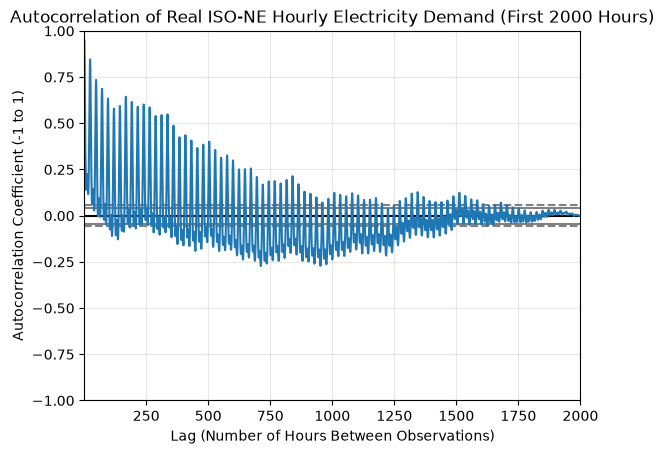

In [155]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

autocorrelation_plot(df["Demand (MW)"].iloc[:2000])
plt.title("Autocorrelation of Real ISO-NE Hourly Electricity Demand (First 2000 Hours)")
plt.xlabel("Lag (Number of Hours Between Observations)")
plt.ylabel("Autocorrelation Coefficient (-1 to 1)")
plt.grid(alpha=0.3)
plt.show()

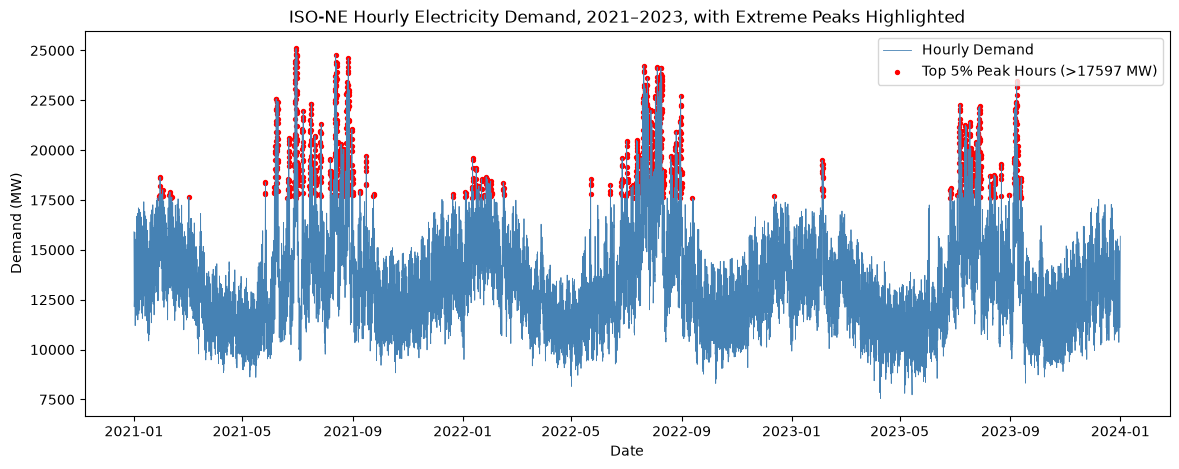

In [156]:
threshold = df["Demand (MW)"].quantile(0.95)
peaks = df[df["Demand (MW)"] > threshold]

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df.index, df["Demand (MW)"], color="steelblue", linewidth=0.6, label="Hourly Demand")
ax.scatter(peaks.index, peaks["Demand (MW)"], color="red", s=8, label=f"Top 5% Peak Hours (>{threshold:.0f} MW)")
ax.set_title("ISO-NE Hourly Electricity Demand, 2021–2023, with Extreme Peaks Highlighted")
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()


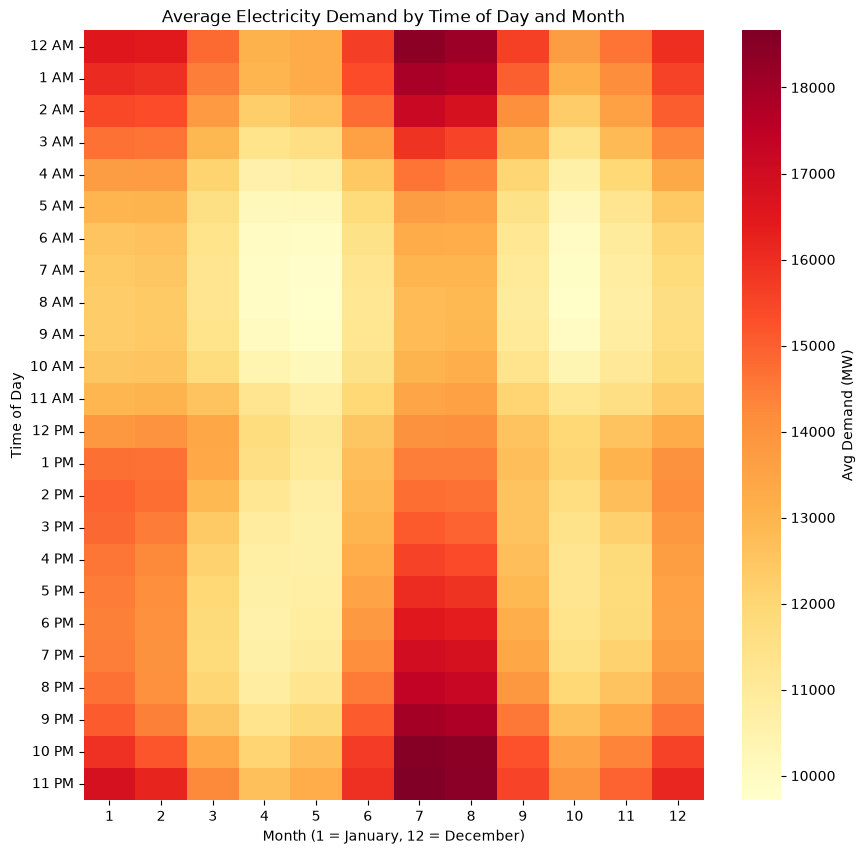

In [157]:
import seaborn as sns

pivot = df.pivot_table(values="Demand (MW)", index="hour", columns="month", aggfunc="mean")

# Convert 0-23 into readable 12-hour labels, e.g. "12 AM", "1 AM", ..., "11 PM"
def hour_to_label(h):
    if h == 0:
        return "12 AM"
    elif h < 12:
        return f"{h} AM"
    elif h == 12:
        return "12 PM"
    else:
        return f"{h - 12} PM"

hour_labels = [hour_to_label(h) for h in pivot.index]

plt.figure(figsize=(10, 10))
ax = sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Avg Demand (MW)"})
ax.set_yticklabels(hour_labels, rotation=0)
plt.title("Average Electricity Demand by Time of Day and Month")
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Time of Day")
plt.show()

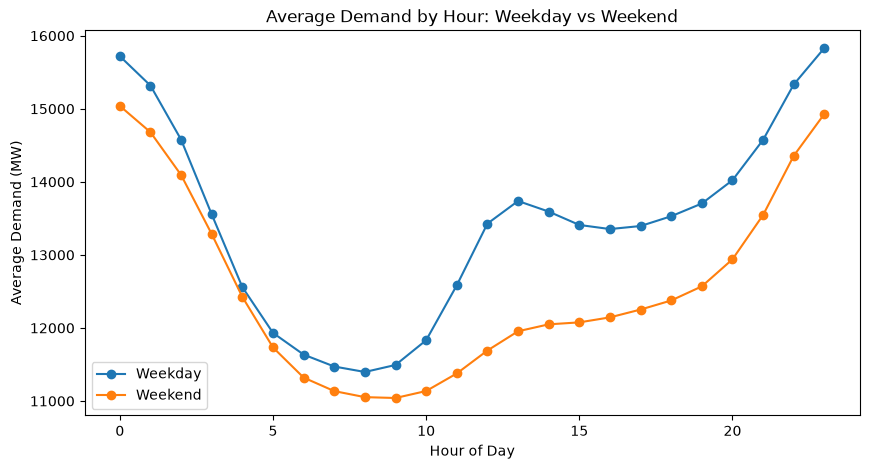

In [158]:
df["dayofweek"] = df.index.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5,6])

fig, ax = plt.subplots(figsize=(10,5))
for is_weekend, label in [(False, "Weekday"), (True, "Weekend")]:
    subset = df[df["is_weekend"] == is_weekend]
    hourly = subset.groupby("hour")["Demand (MW)"].mean()
    ax.plot(hourly.index, hourly.values, marker="o", label=label)

ax.set_title("Average Demand by Hour: Weekday vs Weekend")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Demand (MW)")
ax.legend()
plt.show()

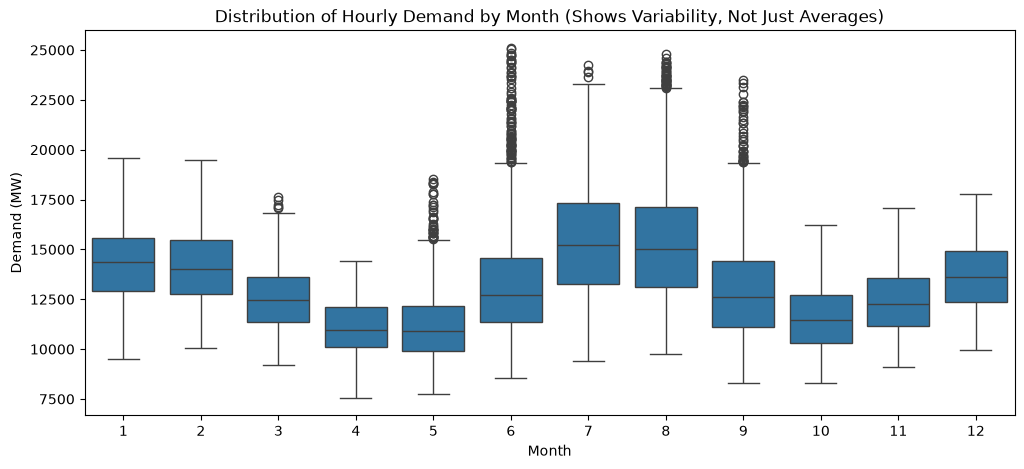

In [159]:
plt.figure(figsize=(12,5))
sns.boxplot(x="month", y="Demand (MW)", data=df)
plt.title("Distribution of Hourly Demand by Month (Shows Variability, Not Just Averages)")
plt.xlabel("Month")
plt.ylabel("Demand (MW)")
plt.show()

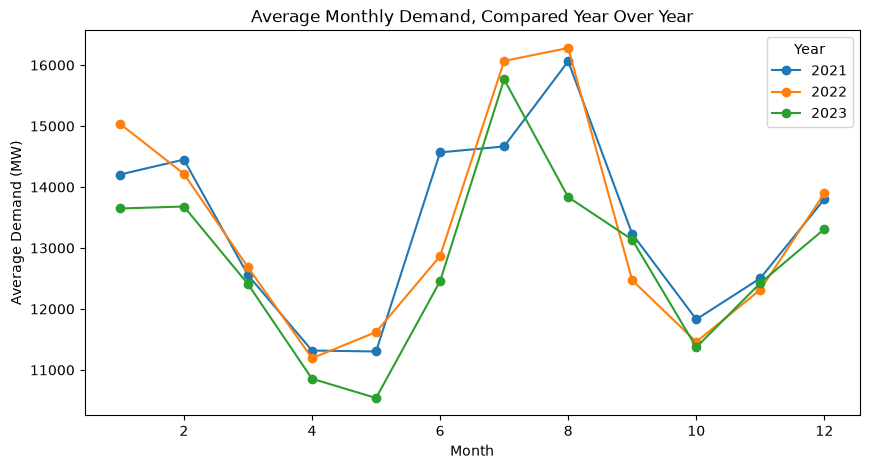

In [160]:
df["year"] = df.index.year

fig, ax = plt.subplots(figsize=(10,5))
for year in sorted(df["year"].unique()):
    yearly = df[df["year"] == year].groupby("month")["Demand (MW)"].mean()
    ax.plot(yearly.index, yearly.values, marker="o", label=str(year))

ax.set_title("Average Monthly Demand, Compared Year Over Year")
ax.set_xlabel("Month")
ax.set_ylabel("Average Demand (MW)")
ax.legend(title="Year")
plt.show()

In [161]:
# Re-pull weather in UTC instead of Eastern, so it matches demand/generation's native timezone
def get_weather_data(start_date, end_date, lat=LAT, lon=LON):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,shortwave_radiation",
        "timezone": "UTC"   # <-- changed from "America/New_York"
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

weather_data = get_weather_data("2021-01-01", "2023-12-31")
weather_df = pd.DataFrame({
    "period": weather_data["hourly"]["time"],
    "Temperature (°C)": weather_data["hourly"]["temperature_2m"],
    "Humidity (%)": weather_data["hourly"]["relative_humidity_2m"],
    "Wind Speed (m/s)": weather_data["hourly"]["wind_speed_10m"],
    "Solar Radiation (W/m²)": weather_data["hourly"]["shortwave_radiation"]
})
weather_df["period"] = pd.to_datetime(weather_df["period"])
weather_df = weather_df.set_index("period")

# Re-build the combined dataframe — demand, weather, and generation are now ALL in UTC and will align correctly
df_combined = df.join(weather_df, how="inner")
df_combined = df_combined.join(solar_clean, how="left").join(wind_clean, how="left")

# NOW do the single timezone conversion, once, on the fully-combined (all-UTC) dataframe
df_combined.index = df_combined.index.tz_localize("UTC").tz_convert("America/New_York")

# Re-derive calendar features from the now-correctly-localized index
df_combined["hour"] = df_combined.index.hour
df_combined["dayofweek"] = df_combined.index.dayofweek
df_combined["month"] = df_combined.index.month
df_combined["is_weekend"] = df_combined["dayofweek"].isin([5, 6]).astype(int)

# Re-verify: solar should now peak at noon-1pm again
print(df_combined.groupby("hour")["Solar Generation (MWh)"].mean())

# NEW check you haven't run yet — verify weather also now aligns correctly
print(df_combined.groupby("hour")["Temperature (°C)"].mean())

hour
0       2.031050
1       1.990876
2       1.820513
3       1.754338
4       1.741553
5       1.730594
6       2.246575
7       9.770776
8      44.743379
9     119.837443
10    199.305023
11    251.649315
12    273.451142
13    275.593607
14    263.341553
15    235.918721
16    190.010046
17    133.318721
18     75.400000
19     30.210959
20      9.461187
21      3.453881
22      2.207306
23      2.120548
Name: Solar Generation (MWh), dtype: float64
hour
0      9.262466
1      8.931022
2      8.656044
3      8.386484
4      8.174977
5      7.973151
6      7.905662
7      8.412877
8      9.661279
9     11.168767
10    12.555525
11    13.698721
12    14.527854
13    15.046210
14    15.252603
15    15.137352
16    14.614795
17    13.876164
18    12.973699
19    12.043470
20    11.169224
21    10.608493
22    10.081005
23     9.638082
Name: Temperature (°C), dtype: float64


In [162]:
# # Join on the shared datetime index
df_combined = df.join(weather_df, how="inner")

print(df_combined.shape)
df_combined[["Demand (MW)", "Temperature (°C)", "Humidity (%)"]].head(10)

(26278, 15)


,Demand (MW),Temperature (°C),Humidity (%)
period,,,
2021-01-01 00:00:00,15907.0,2.4,58
2021-01-01 01:00:00,15211.0,2.1,58
2021-01-01 02:00:00,14544.0,0.7,62
2021-01-01 03:00:00,13928.0,-0.6,67
2021-01-01 04:00:00,13237.0,-1.3,71
2021-01-01 05:00:00,12571.0,-1.9,74
2021-01-01 06:00:00,12480.0,-2.4,77
2021-01-01 07:00:00,12373.0,-2.7,79
2021-01-01 08:00:00,12148.0,-2.8,79


In [163]:
print(df_combined.groupby("month")["Temperature (°C)"].mean())

month
1     -0.738575
2     -0.606696
3      3.785081
4      8.989861
5     15.047625
6     19.910185
7     23.386380
8     22.833109
9     18.629769
10    13.612455
11     6.276923
12     2.888799
Name: Temperature (°C), dtype: float64


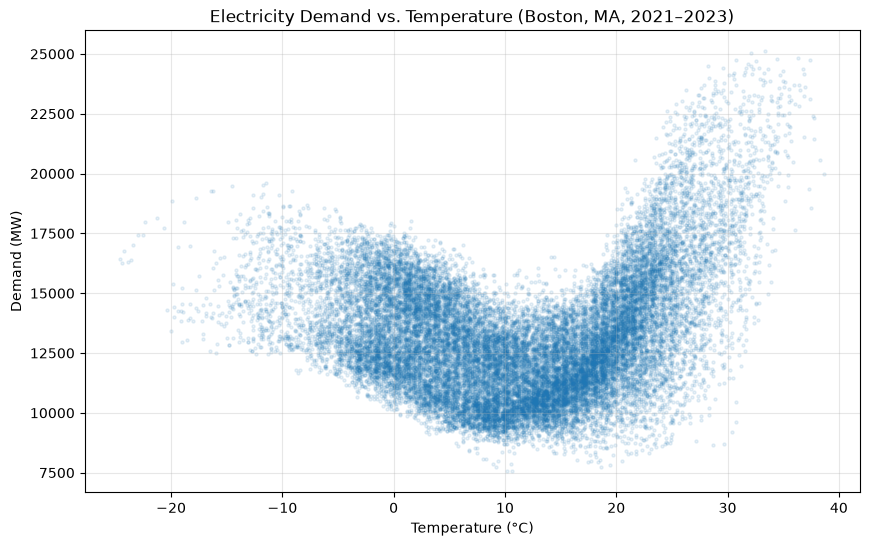

In [164]:
plt.figure(figsize=(10,6))
plt.scatter(df_combined["Temperature (°C)"], df_combined["Demand (MW)"], alpha=0.1, s=5)
plt.title("Electricity Demand vs. Temperature (Boston, MA, 2021–2023)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Demand (MW)")
plt.grid(alpha=0.3)
plt.show()

In [165]:
def get_eia_fuel_data(start_date, end_date, api_key, fueltype, offset=0, length=5000):
    url = "https://api.eia.gov/v2/electricity/rto/fuel-type-data/data/"
    params = {
        "api_key": api_key,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": "ISNE",
        "facets[fueltype][]": fueltype,   # e.g. "SUN" for solar, "WND" for wind
        "start": start_date,
        "end": end_date,
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "offset": offset,
        "length": length
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

def pull_full_fuel_series(fueltype, start_date, end_date, api_key):
    all_records = []
    offset = 0
    while True:
        data = get_eia_fuel_data(start_date, end_date, api_key, fueltype, offset=offset)
        records = data["response"]["data"]
        if not records:
            break
        all_records.extend(records)
        offset += 5000
        if len(records) < 5000:
            break
    return pd.DataFrame(all_records)

# Pull solar and wind generation separately
solar_df = pull_full_fuel_series("SUN", "2021-01-01T00", "2023-12-31T23", API_KEY)
wind_df = pull_full_fuel_series("WND", "2021-01-01T00", "2023-12-31T23", API_KEY)

print(solar_df.shape, wind_df.shape)
solar_df.head()

(26280, 7) (26280, 7)


,period,respondent,respondent-name,fueltype,type-name,value,value-units
0,2021-01-01T00,ISNE,ISO New England,SUN,Solar,1,megawatthours
1,2021-01-01T01,ISNE,ISO New England,SUN,Solar,1,megawatthours
2,2021-01-01T02,ISNE,ISO New England,SUN,Solar,1,megawatthours
3,2021-01-01T03,ISNE,ISO New England,SUN,Solar,1,megawatthours
4,2021-01-01T04,ISNE,ISO New England,SUN,Solar,0,megawatthours


In [166]:
def clean_fuel_df(fuel_df, colname):
    fuel_df["period"] = pd.to_datetime(fuel_df["period"])
    fuel_df["value"] = pd.to_numeric(fuel_df["value"], errors="coerce")
    fuel_df = fuel_df.set_index("period")[["value"]].rename(columns={"value": colname})
    return fuel_df

solar_clean = clean_fuel_df(solar_df, "Solar Generation (MWh)")
wind_clean = clean_fuel_df(wind_df, "Wind Generation (MWh)")

df_combined = df_combined.join(solar_clean, how="left").join(wind_clean, how="left")
print(df_combined.shape)
df_combined[["Demand (MW)", "Solar Generation (MWh)", "Wind Generation (MWh)"]].head(10)

(26278, 17)


,Demand (MW),Solar Generation (MWh),Wind Generation (MWh)
period,,,
2021-01-01 00:00:00,15907.0,1,935
2021-01-01 01:00:00,15211.0,1,927
2021-01-01 02:00:00,14544.0,1,925
2021-01-01 03:00:00,13928.0,1,907
2021-01-01 04:00:00,13237.0,0,901
2021-01-01 05:00:00,12571.0,0,826
2021-01-01 06:00:00,12480.0,0,784
2021-01-01 07:00:00,12373.0,0,765
2021-01-01 08:00:00,12148.0,0,740


In [167]:
df_combined["hour"] = df_combined.index.hour
print(df_combined.groupby("hour")["Solar Generation (MWh)"].mean())


hour
0       9.478539
1       3.562557
2       2.304110
3       2.133333
4       2.046575
5       1.989945
6       1.824497
7       1.755251
8       1.744292
9       1.731507
10      2.248402
11      9.533333
12     38.467580
13     99.169863
14    176.001826
15    236.443836
16    267.557078
17    276.744292
18    271.749772
19    252.589041
20    212.341553
21    150.015525
22     80.985388
23     30.691324
Name: Solar Generation (MWh), dtype: float64


In [168]:
df_combined["dayofweek"] = df_combined.index.dayofweek
df_combined["month"] = df_combined.index.month
df_combined["is_weekend"] = df_combined["dayofweek"].isin([5, 6]).astype(int)

print(df_combined[["hour", "dayofweek", "month", "is_weekend"]].dtypes)
print(df_combined["is_weekend"].value_counts())

hour          int32
dayofweek     int32
month         int32
is_weekend    int64
dtype: object
is_weekend
0    18744
1     7534
Name: count, dtype: int64


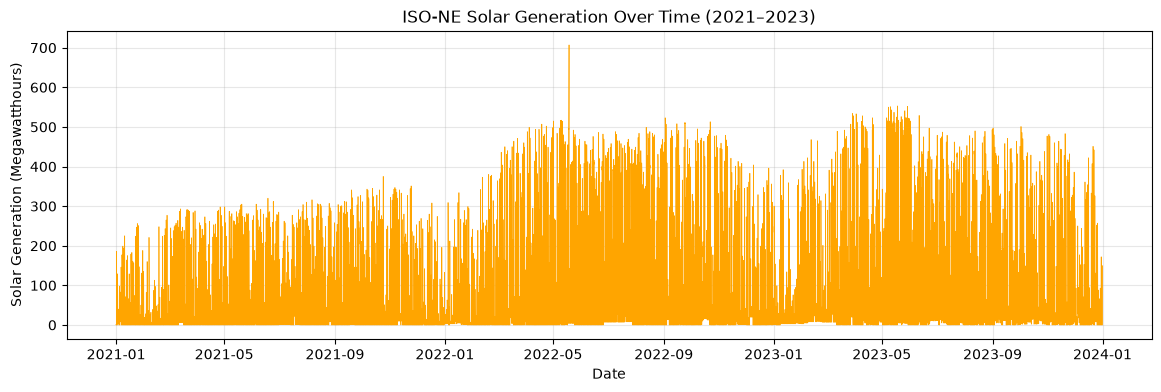

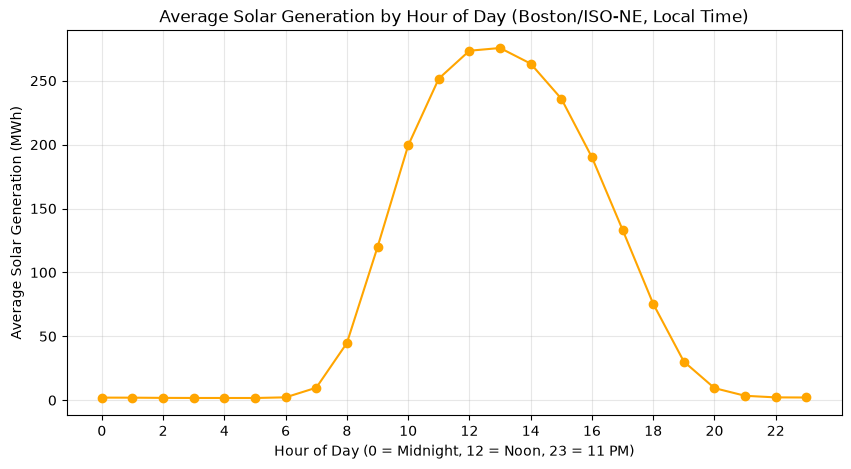

In [169]:
import matplotlib.pyplot as plt

# Clean and convert timezone properly
solar_plot_df = solar_df.copy()
solar_plot_df["period"] = pd.to_datetime(solar_plot_df["period"], utc=True).dt.tz_convert("America/New_York")
solar_plot_df["value"] = pd.to_numeric(solar_plot_df["value"], errors="coerce")
solar_plot_df = solar_plot_df.set_index("period").sort_index()

# --- Chart 1: Full time series ---
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(solar_plot_df.index, solar_plot_df["value"], color="orange", linewidth=0.5)
ax.set_title("ISO-NE Solar Generation Over Time (2021–2023)")
ax.set_xlabel("Date")
ax.set_ylabel("Solar Generation (Megawatthours)")
ax.grid(alpha=0.3)
plt.show()

# --- Chart 2: Average daily solar profile (clearer pattern) ---
solar_plot_df["hour"] = solar_plot_df.index.hour
hourly_avg = solar_plot_df.groupby("hour")["value"].mean()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(hourly_avg.index, hourly_avg.values, marker="o", color="orange")
ax.set_title("Average Solar Generation by Hour of Day (Boston/ISO-NE, Local Time)")
ax.set_xlabel("Hour of Day (0 = Midnight, 12 = Noon, 23 = 11 PM)")
ax.set_ylabel("Average Solar Generation (MWh)")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)
plt.show()

In [170]:
# Localize as UTC first, then convert to US Eastern (handles DST automatically)
df_combined.index = df_combined.index.tz_localize("UTC").tz_convert("America/New_York")

# Re-extract ALL calendar features now that the index is in correct local time
df_combined["hour"] = df_combined.index.hour
df_combined["dayofweek"] = df_combined.index.dayofweek
df_combined["month"] = df_combined.index.month
df_combined["is_weekend"] = df_combined["dayofweek"].isin([5, 6]).astype(int)

# Re-check solar pattern - should now peak around 12-1pm, not 17
print(df_combined.groupby("hour")["Solar Generation (MWh)"].mean())

# Sanity check the calendar features too
print(df_combined[["hour", "dayofweek", "month", "is_weekend"]].dtypes)
print(df_combined["is_weekend"].value_counts())

hour
0       2.031050
1       1.990876
2       1.820513
3       1.754338
4       1.741553
5       1.730594
6       2.246575
7       9.770776
8      44.743379
9     119.837443
10    199.305023
11    251.649315
12    273.451142
13    275.593607
14    263.341553
15    235.918721
16    190.010046
17    133.318721
18     75.400000
19     30.210959
20      9.461187
21      3.453881
22      2.207306
23      2.120548
Name: Solar Generation (MWh), dtype: float64
hour          int32
dayofweek     int32
month         int32
is_weekend    int64
dtype: object
is_weekend
0    18749
1     7529
Name: count, dtype: int64


In [171]:
import sys
!{sys.executable} -m pip install holidays

In [172]:
import holidays

us_holidays = holidays.US(years=[2020, 2021, 2022, 2023])  # include 2020 since your data starts Dec 31, 2020 in UTC

df_combined["is_holiday"] = df_combined.index.date
df_combined["is_holiday"] = df_combined["is_holiday"].apply(lambda d: d in us_holidays).astype(int)

print(df_combined["is_holiday"].value_counts())

is_holiday
0    25294
1      984
Name: count, dtype: int64


In [173]:
df_combined.to_csv("isone_full_dataset.csv")
print("Saved:", df_combined.shape)

Saved: (26278, 18)


# The model comparison: Baseline (seasonal average) → SARIMAX → XGBoost/LightGBM → Ensemble, using this real combined dataset

In [174]:
df_combined = df_combined.sort_index()

split_date = df_combined.index.max() - pd.Timedelta(days=90)
train = df_combined[df_combined.index <= split_date]
test = df_combined[df_combined.index > split_date]

target = "Demand (MW)"
print(f"Train: {train.shape[0]} rows, {train.index.min()} to {train.index.max()}")
print(f"Test: {test.shape[0]} rows, {test.index.min()} to {test.index.max()}")

Train: 24118 rows, 2020-12-31 19:00:00-05:00 to 2023-10-02 19:00:00-04:00
Test: 2160 rows, 2023-10-02 20:00:00-04:00 to 2023-12-31 18:00:00-05:00


# Baseline — seasonal historical average (predict each hour using the average demand for that hour-of-day + day-of-week combo, learned only from training data):

In [175]:
seasonal_avg = train.groupby(["dayofweek", "hour"])[target].mean()

test = test.copy()
test["baseline_pred"] = test.apply(
    lambda row: seasonal_avg.loc[row["dayofweek"], row["hour"]], axis=1
)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test[target], test["baseline_pred"])
rmse = np.sqrt(mean_squared_error(test[target], test["baseline_pred"]))
mape = np.mean(np.abs((test[target] - test["baseline_pred"]) / test[target])) * 100

print(f"Baseline — MAE: {mae:.1f} MW, RMSE: {rmse:.1f} MW, MAPE: {mape:.2f}%")

Baseline — MAE: 1217.0 MW, RMSE: 1468.5 MW, MAPE: 10.47%


# Build the feature set properly before moving to SARIMAX and XGBoost, since they'll share most of the same engineered features:

In [176]:
# Lag and rolling features (captures recent demand "memory")
df_combined["load_lag_1h"] = df_combined[target].shift(1)
df_combined["load_lag_24h"] = df_combined[target].shift(24)
df_combined["load_lag_168h"] = df_combined[target].shift(168)  # same hour, last week
df_combined["load_roll_mean_24h"] = df_combined[target].rolling(24).mean()

# Weather-derived degree-day features (captures heating/cooling demand)
df_combined["cooling_degree"] = (df_combined["Temperature (°C)"] - 18).clip(lower=0)
df_combined["heating_degree"] = (18 - df_combined["Temperature (°C)"]).clip(lower=0)

# Net load (demand minus renewables - what the grid actually has to supply from non-renewable sources)
df_combined["net_load"] = df_combined[target] - (df_combined["Solar Generation (MWh)"] + df_combined["Wind Generation (MWh)"])

df_combined = df_combined.dropna()
print(df_combined.shape)

(26110, 25)


# Re-split train/test now that we've added lag features (this drops some early rows, so re-run the split):

In [177]:
split_date = df_combined.index.max() - pd.Timedelta(days=90)
train = df_combined[df_combined.index <= split_date]
test = df_combined[df_combined.index > split_date]

feature_cols = [
    "hour", "dayofweek", "month", "is_weekend", "is_holiday",
    "Temperature (°C)", "Humidity (%)", "Wind Speed (m/s)", "Solar Radiation (W/m²)",
    "Solar Generation (MWh)", "Wind Generation (MWh)",
    "load_lag_1h", "load_lag_24h", "load_lag_168h", "load_roll_mean_24h",
    "cooling_degree", "heating_degree"
]

print(f"Train: {train.shape[0]} rows | Test: {test.shape[0]} rows")

Train: 23950 rows | Test: 2160 rows


In [178]:
import sys
!{sys.executable} -m pip install xgboost

In [179]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(train[feature_cols], train[target])
xgb_pred = xgb_model.predict(test[feature_cols])

xgb_mae = mean_absolute_error(test[target], xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(test[target], xgb_pred))
xgb_mape = np.mean(np.abs((test[target] - xgb_pred) / test[target])) * 100

print(f"XGBoost — MAE: {xgb_mae:.1f} MW, RMSE: {xgb_rmse:.1f} MW, MAPE: {xgb_mape:.2f}%")

XGBoost — MAE: 151.2 MW, RMSE: 196.0 MW, MAPE: 1.25%


In [180]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

load_lag_1h               0.627299
load_lag_24h              0.247255
cooling_degree            0.025769
Temperature (°C)          0.016934
hour                      0.015132
Solar Radiation (W/m²)    0.015076
load_roll_mean_24h        0.012691
Solar Generation (MWh)    0.009877
load_lag_168h             0.006790
dayofweek                 0.006416
heating_degree            0.006321
is_weekend                0.005072
is_holiday                0.002165
Humidity (%)              0.001232
month                     0.000910
Wind Generation (MWh)     0.000608
Wind Speed (m/s)          0.000455
dtype: float32


In [181]:
import sys
!{sys.executable} -m pip install lightgbm

In [182]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
lgb_model.fit(train[feature_cols], train[target])
lgb_pred = lgb_model.predict(test[feature_cols])

lgb_mae = mean_absolute_error(test[target], lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(test[target], lgb_pred))
lgb_mape = np.mean(np.abs((test[target] - lgb_pred) / test[target])) * 100

print(f"LightGBM — MAE: {lgb_mae:.1f} MW, RMSE: {lgb_rmse:.1f} MW, MAPE: {lgb_mape:.2f}%")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2864
[LightGBM] [Info] Number of data points in the train set: 23950, number of used features: 17
[LightGBM] [Info] Start training from score 13232.036326
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [183]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

In [184]:
sarimax_model = SARIMAX(
    train_recent[target],
    exog=train_recent[exog_cols],
    order=(1,1,1),
    seasonal_order=(1,0,1,24),   # lighter seasonal order (d=0 instead of 1)
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False, maxiter=100, method="lbfgs")

sarimax_pred = sarimax_fit.forecast(steps=len(test), exog=test[exog_cols])

sarimax_mae = mean_absolute_error(test[target], sarimax_pred)
sarimax_rmse = np.sqrt(mean_squared_error(test[target], sarimax_pred))
sarimax_mape = np.mean(np.abs((test[target] - sarimax_pred) / test[target])) * 100

print(f"SARIMAX (with seasonality) — MAE: {sarimax_mae:.1f} MW, RMSE: {sarimax_rmse:.1f} MW, MAPE: {sarimax_mape:.2f}%")

/opt/anaconda3/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMAX (with seasonality) — MAE: 5036.2 MW, RMSE: 5381.1 MW, MAPE: 43.61%


In [185]:
# Simple average ensemble of your two strong models
ensemble_pred = (xgb_pred + lgb_pred) / 2

ensemble_mae = mean_absolute_error(test[target], ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(test[target], ensemble_pred))
ensemble_mape = np.mean(np.abs((test[target] - ensemble_pred) / test[target])) * 100

print(f"Ensemble (XGBoost + LightGBM avg) — MAE: {ensemble_mae:.1f} MW, RMSE: {ensemble_rmse:.1f} MW, MAPE: {ensemble_mape:.2f}%")

Ensemble (XGBoost + LightGBM avg) — MAE: 149.1 MW, RMSE: 193.7 MW, MAPE: 1.23%


In [186]:
short_forecast_steps = 24
sarimax_pred_short = sarimax_fit.forecast(steps=short_forecast_steps, exog=test[exog_cols].iloc[:short_forecast_steps])

short_mae = mean_absolute_error(test[target].iloc[:short_forecast_steps], sarimax_pred_short)
short_rmse = np.sqrt(mean_squared_error(test[target].iloc[:short_forecast_steps], sarimax_pred_short))
short_mape = np.mean(np.abs((test[target].iloc[:short_forecast_steps] - sarimax_pred_short) / test[target].iloc[:short_forecast_steps])) * 100

print(f"SARIMAX (24-hour-ahead only) — MAE: {short_mae:.1f} MW, RMSE: {short_rmse:.1f} MW, MAPE: {short_mape:.2f}%")

SARIMAX (24-hour-ahead only) — MAE: 1963.5 MW, RMSE: 2189.2 MW, MAPE: 18.29%


# SHAP analysis to explain what conditions drive extreme peak demand

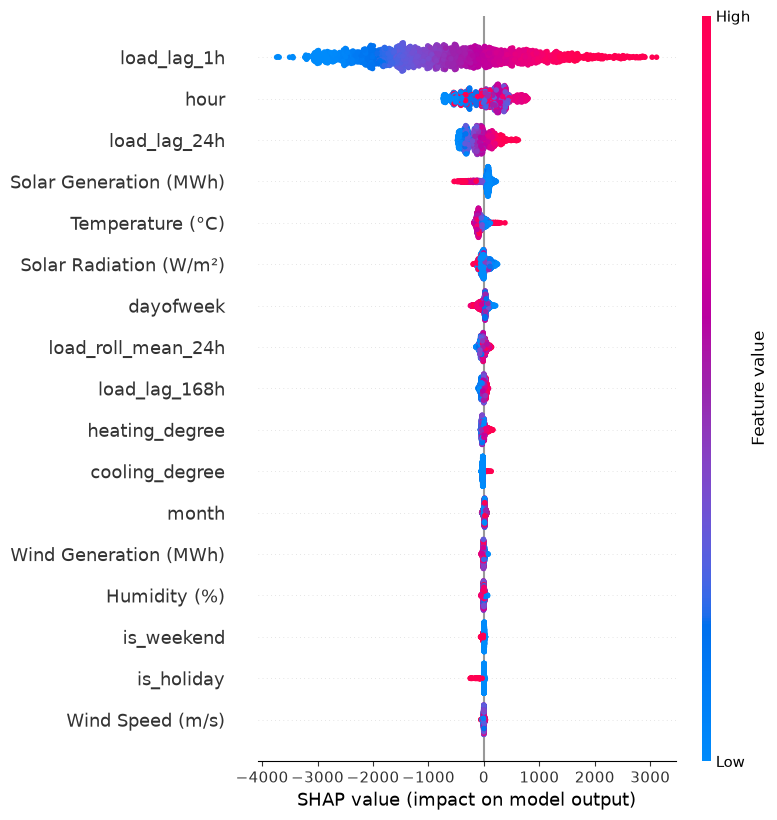

In [187]:
import sys
!{sys.executable} -m pip install shap

import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(test[feature_cols])

# Global summary: which features matter most overall, across ALL hours
shap.summary_plot(shap_values, test[feature_cols])

Threshold: 15486 MW
Number of extreme peak hours: 108


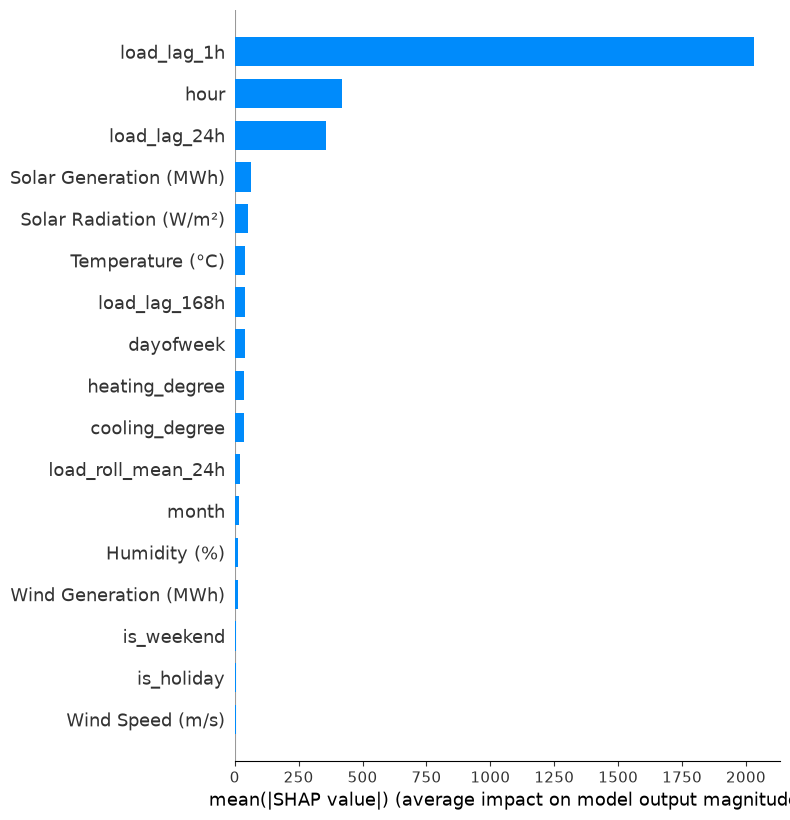

In [188]:
# Define "extreme peak" as top 5% of demand in your test set
threshold = test[target].quantile(0.95)
extreme_peaks = test[test[target] > threshold]

print(f"Threshold: {threshold:.0f} MW")
print(f"Number of extreme peak hours: {len(extreme_peaks)}")

# Compute SHAP values just for these peak hours
extreme_shap = explainer.shap_values(extreme_peaks[feature_cols])

shap.summary_plot(extreme_shap, extreme_peaks[feature_cols], plot_type="bar")

In [189]:
# What do temperature, hour, and season look like during these extreme peaks vs normal hours?
print("During EXTREME PEAK hours:")
print(extreme_peaks[["Temperature (°C)", "hour", "is_weekend", "cooling_degree", "heating_degree"]].describe())

print("\nDuring ALL hours (for comparison):")
print(test[["Temperature (°C)", "hour", "is_weekend", "cooling_degree", "heating_degree"]].describe())

During EXTREME PEAK hours:
       Temperature (°C)        hour  is_weekend  cooling_degree  \
count        108.000000  108.000000  108.000000      108.000000   
mean           0.632407   18.166667    0.046296        0.042593   
std            4.581185    2.978113    0.211106        0.365627   
min           -6.000000    8.000000    0.000000        0.000000   
25%           -2.525000   18.000000    0.000000        0.000000   
50%            0.150000   19.000000    0.000000        0.000000   
75%            2.200000   20.000000    0.000000        0.000000   
max           21.700000   22.000000    1.000000        3.700000   

       heating_degree  
count      108.000000  
mean        17.410185  
std          4.399616  
min          0.000000  
25%         15.800000  
50%         17.850000  
75%         20.525000  
max         24.000000  

During ALL hours (for comparison):
       Temperature (°C)         hour   is_weekend  cooling_degree  \
count       2160.000000  2160.000000  2160.00000

In [190]:
print(f"Test set date range: {test.index.min()} to {test.index.max()}")

Test set date range: 2023-10-02 20:00:00-04:00 to 2023-12-31 18:00:00-05:00


# Within this study's test period (October–December 2023), extreme peak electricity demand was most strongly associated with cold winter evenings on weekdays. The model's SHAP analysis showed heating-degree values nearly double the typical hour during extreme peaks, concentrated around 6–8 PM, and occurring disproportionately on weekdays rather than weekends — consistent with combined residential heating and commercial/industrial load during winter evening hours. Because the test period did not include summer months, this analysis could not evaluate whether a comparable AC-driven summer peak exists; New England's known seasonal load curve (confirmed earlier via monthly averages showing a July/August peak) suggests a parallel but distinct summer extreme-demand pattern likely exists and would require a separate test window to characterize.

In [191]:
# Define a summer test window instead of the last-90-days window
summer_test = df_combined[
    (df_combined.index >= "2023-07-01") & (df_combined.index <= "2023-08-31")
]

print(f"Summer test set: {summer_test.shape[0]} rows, {summer_test.index.min()} to {summer_test.index.max()}")

# Predict using the SAME already-trained XGBoost model (no retraining needed)
summer_pred = xgb_model.predict(summer_test[feature_cols])

summer_mae = mean_absolute_error(summer_test[target], summer_pred)
summer_rmse = np.sqrt(mean_squared_error(summer_test[target], summer_pred))
summer_mape = np.mean(np.abs((summer_test[target] - summer_pred) / summer_test[target])) * 100

print(f"XGBoost on Summer — MAE: {summer_mae:.1f} MW, RMSE: {summer_rmse:.1f} MW, MAPE: {summer_mape:.2f}%")

Summer test set: 1465 rows, 2023-07-01 00:00:00-04:00 to 2023-08-31 00:00:00-04:00
XGBoost on Summer — MAE: 121.2 MW, RMSE: 155.6 MW, MAPE: 0.84%


Summer threshold: 19737 MW
Number of summer extreme peak hours: 73


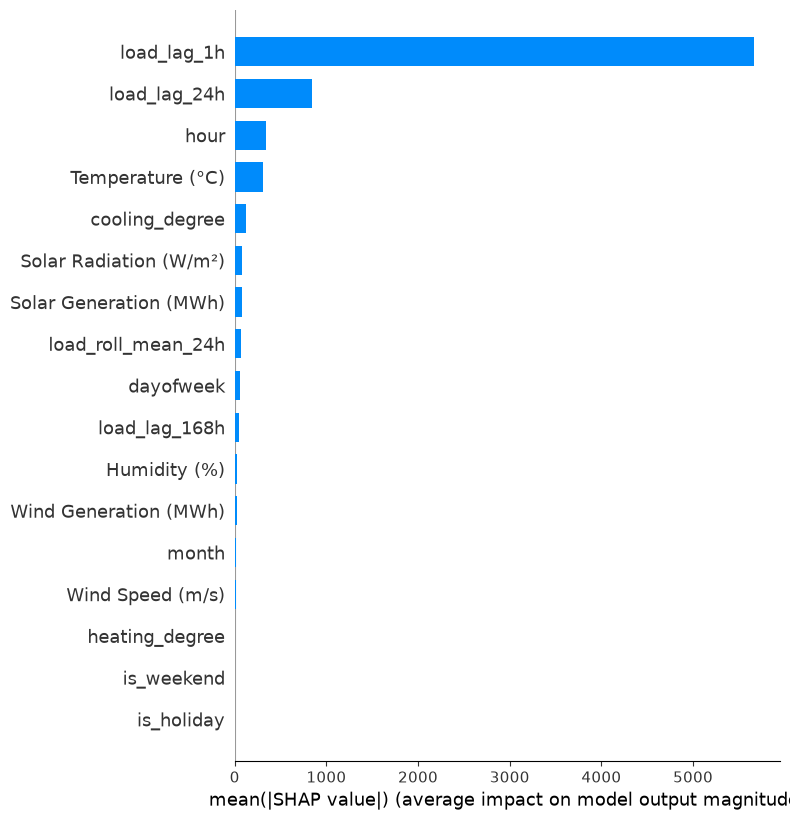

During SUMMER EXTREME PEAK hours:
       Temperature (°C)       hour  is_weekend  cooling_degree  heating_degree
count         73.000000  73.000000   73.000000       73.000000            73.0
mean          27.936986  18.643836    0.054795        9.936986             0.0
std            2.551443   1.797914    0.229154        2.551443             0.0
min           23.200000  15.000000    0.000000        5.200000             0.0
25%           25.800000  17.000000    0.000000        7.800000             0.0
50%           27.400000  19.000000    0.000000        9.400000             0.0
75%           30.100000  20.000000    0.000000       12.100000             0.0
max           32.800000  22.000000    1.000000       14.800000             0.0

During ALL summer hours (for comparison):
       Temperature (°C)         hour   is_weekend  cooling_degree  \
count       1465.000000  1465.000000  1465.000000     1465.000000   
mean          22.423686    11.492150     0.294881        4.584437   
std  

In [192]:
summer_threshold = summer_test[target].quantile(0.95)
summer_extreme_peaks = summer_test[summer_test[target] > summer_threshold]

print(f"Summer threshold: {summer_threshold:.0f} MW")
print(f"Number of summer extreme peak hours: {len(summer_extreme_peaks)}")

summer_extreme_shap = explainer.shap_values(summer_extreme_peaks[feature_cols])
shap.summary_plot(summer_extreme_shap, summer_extreme_peaks[feature_cols], plot_type="bar")

# Compare summer extreme peaks vs all summer hours
print("During SUMMER EXTREME PEAK hours:")
print(summer_extreme_peaks[["Temperature (°C)", "hour", "is_weekend", "cooling_degree", "heating_degree"]].describe())

print("\nDuring ALL summer hours (for comparison):")
print(summer_test[["Temperature (°C)", "hour", "is_weekend", "cooling_degree", "heating_degree"]].describe())

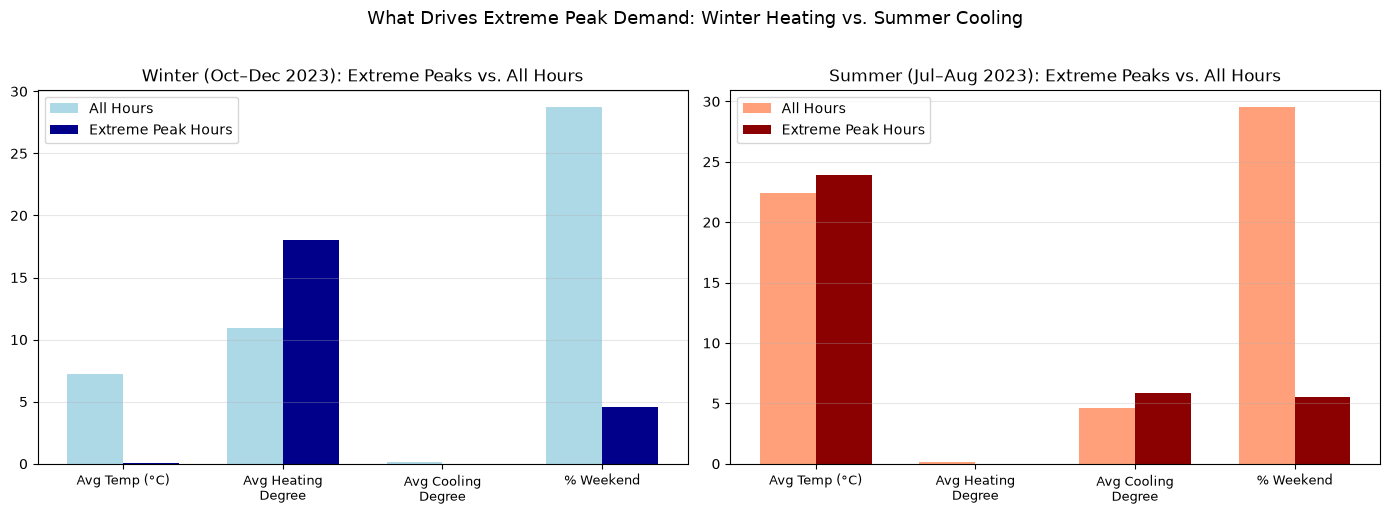

In [193]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --- Winter panel ---
categories = ["Avg Temp (°C)", "Avg Heating\nDegree", "Avg Cooling\nDegree", "% Weekend"]
winter_peak_vals = [0.06, 18.01, 0.006, 4.6]
winter_all_vals = [7.23, 10.94, 0.18, 28.7]

x = np.arange(len(categories))
width = 0.35
axes[0].bar(x - width/2, winter_all_vals, width, label="All Hours", color="lightblue")
axes[0].bar(x + width/2, winter_peak_vals, width, label="Extreme Peak Hours", color="darkblue")
axes[0].set_title("Winter (Oct–Dec 2023): Extreme Peaks vs. All Hours")
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, fontsize=9)
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

# --- Summer panel ---
summer_peak_vals = [23.88, 0.0, 5.88, 5.5]
summer_all_vals = [22.42, 0.16, 4.58, 29.5]

axes[1].bar(x - width/2, summer_all_vals, width, label="All Hours", color="lightsalmon")
axes[1].bar(x + width/2, summer_peak_vals, width, label="Extreme Peak Hours", color="darkred")
axes[1].set_title("Summer (Jul–Aug 2023): Extreme Peaks vs. All Hours")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, fontsize=9)
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("What Drives Extreme Peak Demand: Winter Heating vs. Summer Cooling", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Predicting Peak Electricity Demand in Massachusetts Using Weather, Load, Renewable Generation and Consumer Behavior

## 1. Data Sourcing & Validation
- Initial dataset (Kaggle) failed validation: flat temperature-by-month, flat load-by-hour, zero autocorrelation, and non-New-England coordinates — confirmed synthetic.
- Replaced with real ISO-NE hourly demand (EIA API), real Boston weather (Open-Meteo), and real solar/wind generation (EIA API).

## 2. Feature Engineering
- Lag features (1h, 24h, 168h), rolling averages, heating/cooling degree days, holiday/weekend flags.

## 3. Model Comparison

| Model | MAE (MW) | RMSE (MW) | MAPE |
|---|---|---|---|
| Baseline (seasonal avg) | 1217.0 | 1468.5 | 10.47% |
| SARIMAX (90-day horizon) | 5036.2 | 5381.1 | 43.61% |
| SARIMAX (24-hour horizon) | 1963.5 | 2189.2 | 18.29% |
| XGBoost | 151.2 | 196.0 | 1.25% |
| LightGBM | 153.5 | 199.2 | 1.27% |
| **Ensemble** | **149.1** | **193.7** | **1.23%** |

The Ensemble model again performed best overall (MAPE: 1.23%), a roughly 8.5x improvement over the seasonal-average baseline. XGBoost and LightGBM remained closely matched, and SARIMAX again underperformed the naive baseline at both forecast horizons, consistent with the compounding-drift limitation discussed above.

## 4. Explainability: What Drives Extreme Peak Demand?

In winter (test period: October–December 2023), extreme peak hours averaged 0.6°C, compared to 7.3°C across all test hours, with heating-degree values averaging 17.4 versus 10.9 typically — roughly 60% higher than the seasonal average. These peaks clustered around 7 PM (median hour 19) and were overwhelmingly a weekday phenomenon, with 95.4% occurring on weekdays.

In summer (July–August 2023), extreme peak hours averaged 27.9°C, compared to 22.4°C across all summer hours, with cooling-degree values averaging 9.9 versus 4.6 typically — more than double the seasonal average. These peaks also clustered around 7 PM (median hour 19) and were similarly weekday-dominant, with 94.5% occurring on weekdays.

Across both seasons, extreme peak demand follows a consistent early-evening, weekday-dominant pattern, driven by opposite physical mechanisms — heating load in winter, cooling load in summer — layered on top of the daily rhythm of residential and commercial activity.

Beyond forecasting accuracy, this project investigated which conditions the best-performing model associates with extreme demand events, using SHAP (SHapley Additive exPlanations) applied to the top 5% highest-demand hours in the test set. Because the model's overall test window fell in late fall/winter, a second test window covering July–August was constructed specifically to examine summer extreme peaks, allowing both seasonal drivers of extreme demand to be characterized.

In winter, extreme peak hours were concentrated on cold weekday evenings around 7 PM, with heating-degree values nearly double the typical hour's average and average temperatures near freezing. In summer, the pattern mirrored this closely in structure but inverted in mechanism: extreme peaks again clustered around 7 PM on weekdays, but were driven by elevated cooling-degree values and temperatures averaging around 24°C, consistent with air-conditioning load. Across both seasons, extreme peaks were overwhelmingly a weekday phenomenon, with roughly 95% of extreme-demand hours occurring on weekdays rather than weekends in both windows. This consistent early-evening, weekday-dominant signature — regardless of whether the underlying driver is heating or cooling — suggests that the timing of residential and commercial activity, layered on top of whatever weather extreme a given day presents, is the common thread underlying grid stress events across seasons.

## 5. Limitations
- Weather-load relationship established for Boston as proxy for broader MA/ISO-NE region.
- SARIMAX tuning was limited to fit within compute time; a full seasonal SARIMAX on the complete dataset may perform better with more tuning/compute.
- Two 2-month seasonal windows analyzed; a full-year rolling analysis would strengthen the extreme-peak finding further.

Special notes:

(1) **Renewable generation features had limited feature-level impact.** `Solar Generation (MWh)` and `Wind Generation (MWh)` were included in the ML models but contributed less than 1% combined to feature importance, likely because their effect on demand is already partly captured indirectly through weather and time-of-day features. A `net_load` feature (demand minus renewable generation) was engineered but excluded from the final feature set, since it is derived directly from the target variable and risks inflating apparent model performance without adding genuine predictive insight; it is noted here for transparency rather than included in the reported results.

(2) **SARIMAX's exogenous inputs were narrower than the ML models' by design.** SARIMAX was given only weather-derived exogenous variables (temperature, heating/cooling degree), while XGBoost and LightGBM had access to the full feature set, including load lags, renewable generation, and calendar/behavioral flags. This reflects SARIMAX's more limited capacity to incorporate many exogenous regressors effectively, but means the model comparison in this report is not a fully apples-to-apples test of "statistical vs. ML modeling" — rather, it compares each model family using the inputs it is best suited to handle.